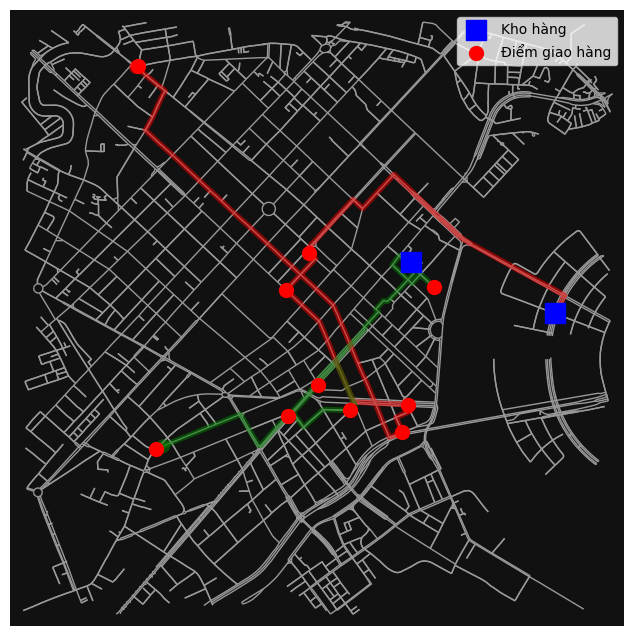

In [30]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import random

center = (10.776, 106.699)
G = ox.graph_from_point(center, dist=2000, network_type='drive')
nodes = list(G.nodes)

depots = random.sample(nodes, 2)
delivery_points = random.sample(nodes, 10)

def find_efficient_route(graph, start_node, points):
    current_node = start_node
    unvisited = points.copy()
    full_route = []

    while unvisited:
        next_node = min(unvisited, key=lambda p: nx.shortest_path_length(graph, current_node, p, weight='length'))
        route = nx.shortest_path(graph, current_node, next_node, weight='length')
        full_route.extend(route[:-1])
        current_node = next_node
        unvisited.remove(next_node)
    return full_route
route1 = find_efficient_route(G, depots[0], delivery_points[:5])
route2 = find_efficient_route(G, depots[1], delivery_points[5:])

fig, ax = ox.plot_graph_routes(G, [route1, route2], route_colors=['r', 'g'], route_linewidth=4, node_size=0, show=False, close=False)

depot_lats = [G.nodes[d]['y'] for d in depots]
depot_lons = [G.nodes[d]['x'] for d in depots]
ax.scatter(depot_lons, depot_lats, c='blue', s=200, marker='s', label='Kho hàng', zorder=5)

point_lats = [G.nodes[p]['y'] for p in delivery_points]
point_lons = [G.nodes[p]['x'] for p in delivery_points]
ax.scatter(point_lons, point_lats, c='red', s=100, label='Điểm giao hàng', zorder=5)

plt.legend()
plt.show()